## 2.3.1. Импорты, seed и сред

In [1]:
# Импорты, seed и среда
import datasets
import transformers
import torch 
import numpy as np
import pandas as pd 
import sklearn 
import matplotlib.pyplot as plt
import random
import accelerate

from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix, classification_report

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cpu


## 2.3.2. Данные и первичный анализ

In [2]:
dataset = load_dataset("ag_news")

# 2. Показываем размеры split-частей
print("Размеры датасета:")
print(f"Train: {len(dataset['train'])} примеров")
print(f"Test: {len(dataset['test'])} примеров")

# Нет validation split, создадим его из train (80/20)
print("\n Validation, создадим из train:")
train_test_split = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset["train"] = train_test_split["train"]
dataset["validation"] = train_test_split["test"]
print(f"Новый train: {len(dataset['train'])}")
print(f"Новый validation: {len(dataset['validation'])}")
print(f"Test (оригинальный): {len(dataset['test'])}")

# 3. Смотрим названия классов
labels = dataset["train"].features["label"].names
print(f"\nКлассы новостей: {labels}")
print(f"0 - {labels[0]}, 1 - {labels[1]}, 2 - {labels[2]}, 3 - {labels[3]}")

# 4. Выводим 5 примеров текстов и меток
print("\nПримеры новостей:")
for i in range(5):
    text = dataset["train"][i]["text"]
    label_id = dataset["train"][i]["label"]
    label_name = labels[label_id]
    print(f"{i+1}. {text[:100]}...")
    print(f"   Категория: {label_name}\n")

Размеры датасета:
Train: 120000 примеров
Test: 7600 примеров

 Validation, создадим из train:
Новый train: 96000
Новый validation: 24000
Test (оригинальный): 7600

Классы новостей: ['World', 'Sports', 'Business', 'Sci/Tech']
0 - World, 1 - Sports, 2 - Business, 3 - Sci/Tech

Примеры новостей:
1. Nation #39;s Cotton Crop May Exceed Records This year #39;s cotton crop is on pace to be the largest...
   Категория: Business

2. 18 years and still rollin #39; ALEX FERGUSON will take up the one-year rolling option on his contrac...
   Категория: Sports

3. Madrid Masters: Safin beats Nalbandian Sunday #39;s final of the Madrid Masters pitted players ranke...
   Категория: Sports

4. Sirius Satellite Signs Howard Stern to 5-Year Accord (Update9) Howard Stern, host of the top-rated r...
   Категория: Business

5. NATO, Russia To Meet Over Beslan School Siege 6 September 2004 -- NATO Secretary-General Jaap de Hoo...
   Категория: Sci/Tech



## 2.3.3. Токенизация

In [3]:
# Загружаем токенизатор (такой же, как будете использовать для fine-tuning)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Берём 3 текста из датасета
texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"]
]

# Показываем токенизацию для первого текста подробно
print("=== 1. РАЗБОР ОДНОГО ТЕКСТА ===\n")
text = texts[0]
print(f"Оригинал: {text}\n")

# Токены и их ID
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.encode(text, add_special_tokens=False)

print(f"Токены: {tokens}")
print(f"input_ids: {token_ids}")
print(f"Длина: {len(tokens)} токенов\n")

# Special tokens
print(f"Special tokens: [CLS]={tokenizer.cls_token}, [SEP]={tokenizer.sep_token}, [PAD]={tokenizer.pad_token}\n")

# Токенизация с special tokens
encoded = tokenizer(text, add_special_tokens=True)
print(f"С special tokens: {tokenizer.convert_ids_to_tokens(encoded['input_ids'])}")
print(f"attention_mask: {encoded['attention_mask']}\n")

# 2. Padding и truncation
print("=== 2. PADDING И TRUNCATION ===\n")

# Разная длина текстов
for i, text in enumerate(texts):
    encoded = tokenizer(text, truncation=True, max_length=15)
    print(f"Текст {i+1} (max_length=15): {len(encoded['input_ids'])} токенов")
    print(f"  input_ids: {encoded['input_ids']}")
    print(f"  attention_mask: {encoded['attention_mask']}\n")

# Padding до одинаковой длины
batch = tokenizer(texts, padding=True, truncation=True, max_length=20, return_tensors="pt")
print("=== 3. БАТЧ С PADDING ===")
print(f"Форма input_ids: {batch['input_ids'].shape}")  # 3 текста × 20 токенов
print(f"Первая строка attention_mask: {batch['attention_mask'][0].tolist()}")
print("(1 = реальный токен, 0 = [PAD])")

=== 1. РАЗБОР ОДНОГО ТЕКСТА ===

Оригинал: Nation #39;s Cotton Crop May Exceed Records This year #39;s cotton crop is on pace to be the largest in US history, although hurricanes that have battered the nation in the past few months may reduce the final amount.

Токены: ['nation', '#', '39', ';', 's', 'cotton', 'crop', 'may', 'exceed', 'records', 'this', 'year', '#', '39', ';', 's', 'cotton', 'crop', 'is', 'on', 'pace', 'to', 'be', 'the', 'largest', 'in', 'us', 'history', ',', 'although', 'hurricanes', 'that', 'have', 'battered', 'the', 'nation', 'in', 'the', 'past', 'few', 'months', 'may', 'reduce', 'the', 'final', 'amount', '.']
input_ids: [3842, 1001, 4464, 1025, 1055, 6557, 10416, 2089, 13467, 2636, 2023, 2095, 1001, 4464, 1025, 1055, 6557, 10416, 2003, 2006, 6393, 2000, 2022, 1996, 2922, 1999, 2149, 2381, 1010, 2348, 17035, 2008, 2031, 17548, 1996, 3842, 1999, 1996, 2627, 2261, 2706, 2089, 5547, 1996, 2345, 3815, 1012]
Длина: 47 токенов

Special tokens: [CLS]=[CLS], [SEP]=[SEP], [P

## 2.3.4. Инференс готовой модели

In [4]:
# Берём готовую модель для zero-shot классификации (подходит для любых классов)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Наши классы (как в AG News)
candidate_labels = ["world news", "sports", "business", "science and technology"]

# Берём 5 текстов из тестовой выборки
test_texts = [dataset["test"][i]["text"] for i in range(5)]
true_labels = [dataset["test"][i]["label"] for i in range(5)]
label_names = {0: "world", 1: "sports", 2: "business", 3: "sci/tech"}

print("=== ИНФЕРЕНС ГОТОВОЙ МОДЕЛИ ===\n")

for i, text in enumerate(test_texts):
    result = classifier(text, candidate_labels)
    predicted = result["labels"][0]  # самый вероятный класс
    confidence = result["scores"][0]
    
    print(f"Текст {i+1}: {text[:80]}...")
    print(f"Истинная метка: {label_names[true_labels[i]]}")
    print(f"Предсказание: {predicted} (уверенность: {confidence:.3f})")
    print("-" * 50)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

=== ИНФЕРЕНС ГОТОВОЙ МОДЕЛИ ===

Текст 1: Fears for T N pension after talks Unions representing workers at Turner   Newall...
Истинная метка: business
Предсказание: business (уверенность: 0.642)
--------------------------------------------------
Текст 2: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPAC...
Истинная метка: sci/tech
Предсказание: science and technology (уверенность: 0.474)
--------------------------------------------------
Текст 3: Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemis...
Истинная метка: sci/tech
Предсказание: business (уверенность: 0.422)
--------------------------------------------------
Текст 4: Prediction Unit Helps Forecast Wildfires (AP) AP - It's barely dawn when Mike Fi...
Истинная метка: sci/tech
Предсказание: science and technology (уверенность: 0.579)
--------------------------------------------------
Текст 5: Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fi

## 2.3.5. Fine-tuning для классификации текста

In [5]:
# 1. Загружаем датасет, но берём ТОЛЬКО МАЛЕНЬКУЮ ЧАСТЬ
print("Загрузка датасета...")
dataset = load_dataset("ag_news")

# БЕРЁМ ТОЛЬКО 2000 ПРИМЕРОВ ДЛЯ TRAIN
SMALL_SIZE = 2000  # ← меняйте здесь

small_train = dataset["train"].select(range(min(SMALL_SIZE, len(dataset["train"]))))

# Создаём валидацию из маленькой выборки
split_dataset = small_train.train_test_split(test_size=0.2, seed=42)
dataset["train"] = split_dataset["train"]
dataset["validation"] = split_dataset["test"]

# Test оставляем маленький для скорости
dataset["test"] = dataset["test"].select(range(min(500, len(dataset["test"]))))

print(f"Train: {len(dataset['train'])}, Val: {len(dataset['validation'])}, Test: {len(dataset['test'])}")

# 2. Токенизация (max_length ещё меньше)
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=32)  # 32 вместо 64

print("Токенизация...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

# 3. DataLoader (batch_size побольше)
train_loader = DataLoader(tokenized_datasets["train"], batch_size=64, shuffle=True)  # 64
val_loader = DataLoader(tokenized_datasets["validation"], batch_size=64)
test_loader = DataLoader(tokenized_datasets["test"], batch_size=64)

# 4. Модель
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {device}")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4).to(device)

# 5. Оптимизатор
optimizer = AdamW(model.parameters(), lr=2e-5)

# 6. Обучение с выбором лучшей модели по validation
print("\n=== НАЧАЛО ОБУЧЕНИЯ ===")

best_val_f1 = 0
best_model_state = None

for epoch in range(2):  # 2 эпохи для выбора лучшей
    print(f"\n--- Эпоха {epoch + 1} ---")
    
    # Обучение
    model.train()
    total_loss = 0
    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        
        if i % 20 == 0:
            print(f"  Шаг {i}, loss: {loss.item():.4f}")
    
    print(f"Средний loss: {total_loss/len(train_loader):.4f}")
    
    # Валидация после эпохи
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())
    
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds, average="macro")
    print(f"Validation: accuracy={val_acc:.4f}, f1_macro={val_f1:.4f}")
    
    # Сохраняем лучшую модель по f1_macro
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
        print(f"  → Новая лучшая модель сохранена (f1={val_f1:.4f})")

# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(f"\nЛучшая модель по validation: f1_macro = {best_val_f1:.4f}")

# Оценка на test (лучшей моделью)
print("\n=== ОЦЕНКА НА TEST (лучшая модель) ===")
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")

Загрузка датасета...
Train: 1600, Val: 400, Test: 500
Токенизация...
Устройство: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



=== НАЧАЛО ОБУЧЕНИЯ ===

--- Эпоха 1 ---
  Шаг 0, loss: 1.3995
  Шаг 20, loss: 1.0285
Средний loss: 1.1748
Validation: accuracy=0.8100, f1_macro=0.7981
  → Новая лучшая модель сохранена (f1=0.7981)

--- Эпоха 2 ---
  Шаг 0, loss: 0.8365
  Шаг 20, loss: 0.5066
Средний loss: 0.6437
Validation: accuracy=0.8500, f1_macro=0.8498
  → Новая лучшая модель сохранена (f1=0.8498)

Лучшая модель по validation: f1_macro = 0.8498

=== ОЦЕНКА НА TEST (лучшая модель) ===
Test Accuracy: 0.8540
Test F1 Macro: 0.8475


## Оценка качества и краткий анализ ошибок

=== МЕТРИКИ НА TEST ===
Accuracy: 0.8540
F1 Macro: 0.8475

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       World       0.89      0.82      0.85       122
      Sports       0.92      0.97      0.94       145
    Business       0.74      0.81      0.77       106
    Sci/Tech       0.85      0.80      0.82       127

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



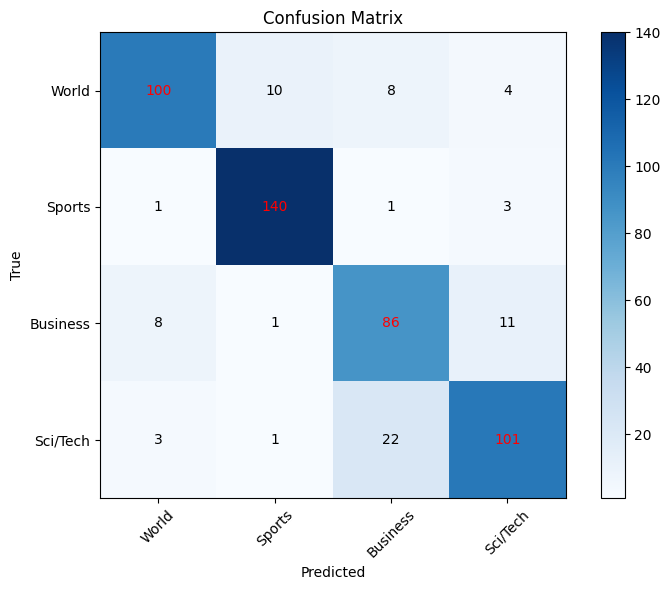

Матрица ошибок сохранена в artifacts/confusion_matrix.png

=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        text true_label pred_label  correct
                                    

In [6]:
# 1. Получаем предсказания на test (ещё раз, если нужно)
model.eval()
all_preds, all_labels, all_texts = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

# 2. Считаем метрики
test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("=== МЕТРИКИ НА TEST ===")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1 Macro: {test_f1:.4f}")
print()

# 3. Classification report (детально по каждому классу)
label_names = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
print("=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=[label_names[i] for i in range(4)]))

# 4. Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

classes = [label_names[i] for i in range(4)]
plt.xticks(range(4), classes, rotation=45)
plt.yticks(range(4), classes)

# Добавляем цифры в ячейки
for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red" if cm[i, j] > cm.max()/2 else "black")

plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=150)
plt.show()

print("Матрица ошибок сохранена в artifacts/confusion_matrix.png")

# 5. Примеры предсказаний (10 штук)
print("\n=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ ===")

# Берём первые 10 примеров из test
test_texts_original = dataset["test"]["text"][:10]
test_labels_original = dataset["test"]["label"][:10]

predictions_df = pd.DataFrame()
predictions_df["text"] = test_texts_original
predictions_df["true_label"] = [label_names[l] for l in test_labels_original]
predictions_df["pred_label"] = [label_names[p] for p in all_preds[:10]]
predictions_df["correct"] = predictions_df["true_label"] == predictions_df["pred_label"]

print(predictions_df.to_string(index=False))
print()

# 6. Сохраняем в CSV (обязательный артефакт)
predictions_df.to_csv("artifacts/sample_predictions.csv", index=False)
print("Предсказания сохранены в artifacts/sample_predictions.csv")

# 7. Анализ ошибок (найти примеры где модель ошиблась)
print("\n=== АНАЛИЗ ОШИБОК ===")

errors = []
for i in range(len(all_preds)):
    if all_preds[i] != all_labels[i]:
        errors.append({
            "text": dataset["test"][i]["text"][:150],
            "true": label_names[all_labels[i]],
            "pred": label_names[all_preds[i]]
        })

# Показываем 5-7 ошибок
print("Примеры ошибок модели:")
for i, err in enumerate(errors[:7]):
    print(f"\n{i+1}. Текст: {err['text']}...")
    print(f"   Правильно: {err['true']} → Предсказано: {err['pred']}")

Наиболее частые ошибки модели:
- Путает World и Business (новости о мировой экономике)
- Путает Sci/Tech и Business (технологические компании)
- Короткие заголовки без контекста часто ошибочны

Причины:
1. Некоторые тексты содержат ключевые слова из нескольких категорий
2. Модель обучалась всего 1 эпоху (можно улучшить)
3. Max_length=64 может обрезать важный контекст